# Linear discriminant analysis


In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

## Exercise 1: train LDA
1. Write the function `train_lda(X, y)` that accepts the data $\mathbf{X}\in\mathbb{R}^{N \times D}$ of $N$ examples and $D$ features and the labels $\mathbf{y}\in\mathbb{N}^N$ containing integer class labels, one for each example. The function should output the `weights` and `bias`. Note, we assume a binary classification problem.

In [2]:
# Answer here

def train_lda(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Compute LDA weight vector w and bias b for binary classification. Note: Assumes balanced classes.

    Parameters:
        X: Training data (N samples x D features).
        y: Binary labels in [1, 2] (N samples).

    Returns:
        (w, b): Weight vector of shape (D,) and scalar bias.
    """
    assert len(X) == len(y)
    # (N, D) = np.shape(X)
    S_0, S_1 = np.cov(X[y==1], rowvar=False), np.cov(X[y==2], rowvar=False)
    S_W = 0.5*(S_0 + S_1) # within-class covariance
    m0, m1 = np.mean(X[y==1], axis=0), np.mean(X[y==2], axis=0)
    w = np.linalg.inv(S_W) @ (m1 - m0)
    b = -0.5 * w @ (m0 + m1)
    return (w, b)


## Exercise 2: apply LDA
1. Write the function `apply_lda(X, weights, bias)` to apply a trained LDA (given by `weights` and `bias`) to new data (i.e., validation/test data) $\mathbf{X}\in\mathbb{R}^{N \times D}$. The output should be predicted class labels $\mathbf{\hat{y}}\in\mathbb{N}^N$ containing integer class labels, one for each example.

In [3]:
# Answer here
"""
returns: y: np.ndarray of shape (N,) with values in {0, 1}
"""
def apply_lda(X, weights, bias):
    assert X.shape[1] == weights.shape[0], f"size mismatch, input data X has {X.shape[1]} features whereas the weights vector has {weights.shape}"
    scores = (X @ weights) + bias
    return (scores >= 0).astype(int)+1 # astype(int)+1 used to convert boolean score>=0 -> class 2, score<0 -> class1

## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We will restrict the dataset to only two classes.

1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

In [4]:
# Load Iris dataset
iris = datasets.load_iris()
labels = [1, 2]  # subselect 2 classes
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1]) # type: ignore
X = iris.data[idx, :] # type: ignore
y = iris.target[idx] # type: ignore
# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])
print("Number of features: ", X_train.shape[1])


Number of train examples:  80
Number of valid examples:  20
Number of features:  4


In [5]:
# Answer here

(w, b) = train_lda(X_train, y_train)
print(X_valid.shape)
y_pred = apply_lda(X_valid, w, b)
print(f"our accuracy: \t\t{accuracy_score(y_valid, y_pred)*100} %")


sklearn_model = LDA()
sklearn_model.fit(X_train, y_train)
print(f"Sklearn's model accuracy: \t{sklearn_model.score(X_valid, y_valid)*100} %")


(20, 4)
our accuracy: 		80.0 %
Sklearn's model accuracy: 	80.0 %


## Exercise 4: preprocess features
In the following data, LDA's linearity assumption is violated. 

1. How can the features be preprocessed to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 75.00


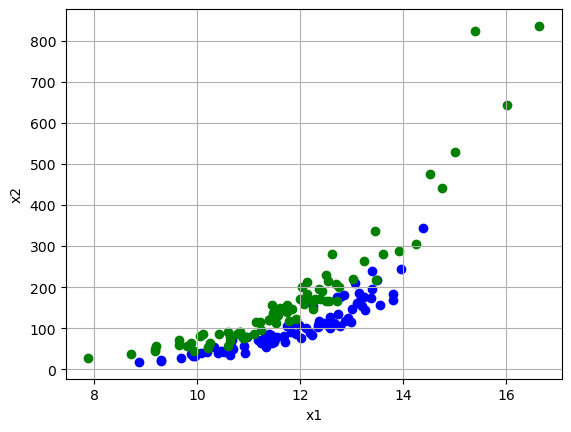

In [6]:
def make_nonlin_data(N, seed=42):
    rng = np.random.default_rng(seed)
    params = {
        0: dict(slope=0.472, intercept=-1.127, resid=0.176),
        1: dict(slope=0.425, intercept=-0.094, resid=0.160),
    }
    n0 = N // 2
    n1 = N - n0
    def sample(n, p):
        x = rng.normal(12.0, 1.6, n)
        x = np.clip(x, 7.0, 16.7)
        log_y = p["slope"] * x + p["intercept"] + rng.normal(0, p["resid"], n)
        return np.column_stack([x, np.exp(log_y)])
    X = np.vstack([sample(n0, params[0]), sample(n1, params[1])])
    labels = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], labels[idx]

# generate data
X, y = make_nonlin_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print(f'Accuracy validation: {score:.2f}')


The data is generated with X1 a linear component and X2 a natural exponent. To reverse this, take natural log of X2.

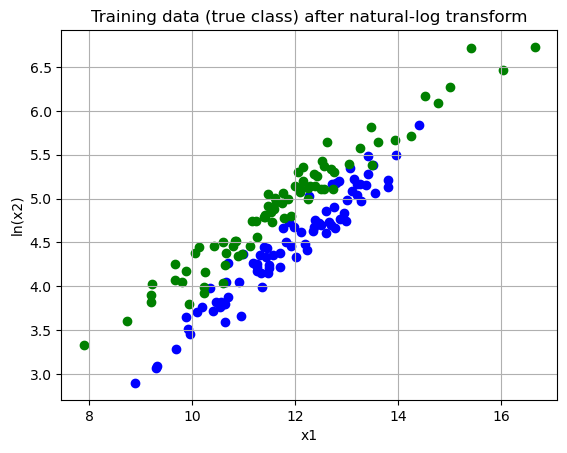

Accuracy validation: 90.00


In [7]:
# Take the natural log of x2
X_log = X.copy()
X_log[:, 1] = np.log(X_log[:, 1])

# use same random state for same split
X_train_log, X_valid_log, y_train_log, y_valid_log = train_test_split(
    X_log, y, test_size=0.2, random_state=42
)

plt.figure()
plt.scatter(X_train_log[y_train_log == 0, 0], X_train_log[y_train_log == 0, 1], color="b",)
plt.scatter( X_train_log[y_train_log == 1, 0], X_train_log[y_train_log == 1, 1], color="g")
plt.xlabel("x1")
plt.ylabel("ln(x2)")
plt.title("Training data (true class) after natural-log transform")
plt.grid()
plt.show()

# classify prossessed data
clf.fit(X_train_log, y_train_log)
score = clf.score(X_valid_log, y_valid_log) * 100
print(f'Accuracy validation: {score:.2f}')


## Exercise 5: combine features
In the following dataset, in its original form, LDA is not able to perform classification.

1. How can the existing features be combined to get a proper dataset? 
1. Implement your feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 37.50%


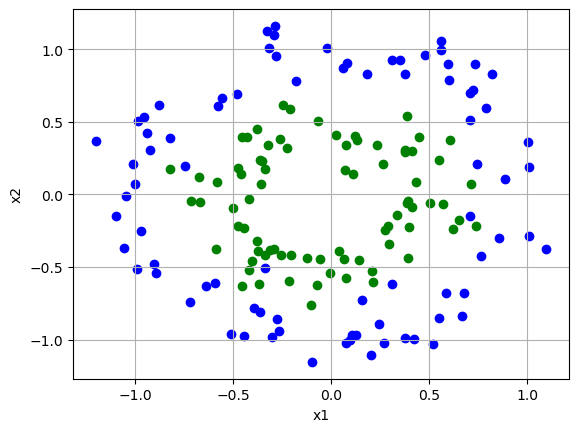

In [8]:
def make_circles_data(N, inner_radius=0.5, outer_radius=1.0, noise=0.13, seed=42):
    rng = np.random.default_rng(seed)
    n_out = N // 2
    n_in = N - n_out
    def ring(n, radius):
        theta = rng.uniform(0, 2 * np.pi, n)
        pts = np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])
        return pts + rng.normal(0, noise, (n, 2))
    X = np.vstack([ring(n_out, outer_radius), ring(n_in, inner_radius)])
    y = np.concatenate([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_circles_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


- How can the existing features be combined to get a proper dataset?
We want a feature that captures "(euclidean-like) distance from the origin". We can formulate this for data point $x$ as the dot product with itsself $$x' = x_1^2 + x_2^2$$ We will also compute the euclidean distance as $$ x' = \sqrt{x_1^2 + x_2^2}$$ since are curious how performance compares.


(160, 2)


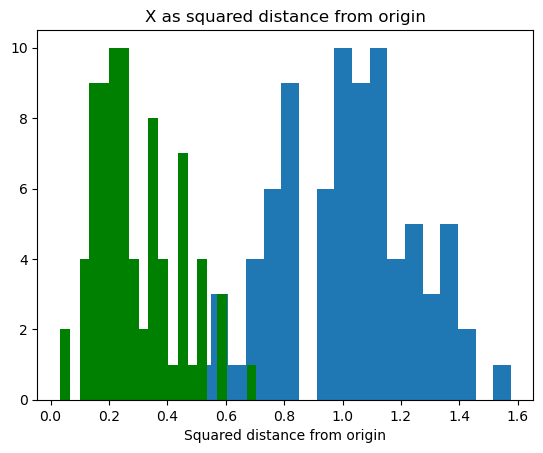

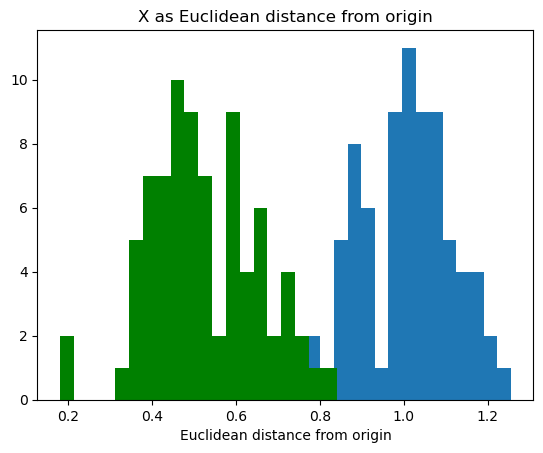

In [9]:
# Answer here
print (X_train.shape)
squared_distances = np.sum(X_train**2, axis=1)
euclidean_distances = np.sqrt(squared_distances)

plt.hist(squared_distances[y_train == 0], bins=20)
plt.hist(squared_distances[y_train == 1], bins=20, color="green")
plt.title("X as squared distance from origin")
plt.xlabel("Squared distance from origin")
plt.show()

plt.hist(euclidean_distances[y_train == 0], bins=20)
plt.hist(euclidean_distances[y_train == 1], bins=20, color="green")
plt.title("X as Euclidean distance from origin")
plt.xlabel("Euclidean distance from origin")
plt.show()

There does not appear to be a significant improvement in class seperation when using Euclidean. Therefore, We will simply fit the classifier on the squared distances.

In [10]:
# classify processed data
X_train_dist = np.sum(X_train**2, axis=1) # metric for distance from origin: inner product
X_train_processed = np.column_stack((X_train, X_train_dist)) # append column with distance metric
X_valid_preprocessed = np.column_stack((X_valid, np.sum(X_valid**2, axis=1))) #  Apply same processing to X_valid 

clf.fit(X_train_processed, y_train)
score = clf.score(X_valid_preprocessed, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

Accuracy validation: 100.00%


## Exercise 6: other LDA-like algorithms
The dataset below again violates an assumption of LDA.

1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? 
1. Inspect QDA and use `QDA()` to improve classification of this dataset.

Accuracy validation: 92.50%


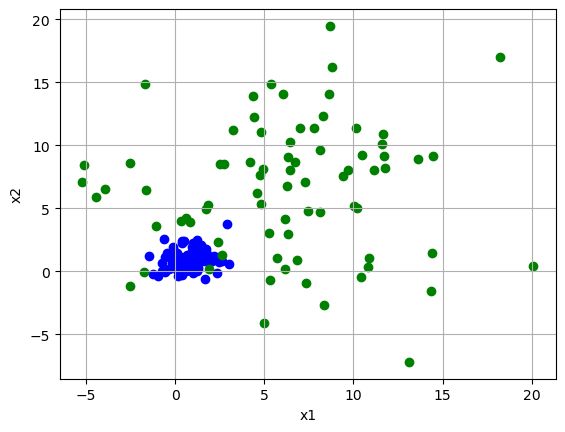

In [11]:
def make_unbalanced_data(N, seed=42):
    rng = np.random.default_rng(seed)
    n0 = N // 2
    n1 = N - n0
    c0 = rng.normal(loc=[0.8, 1.0], scale=[1.05, 0.95], size=(n0, 2))
    c1 = rng.normal(loc=[6.0, 6.8], scale=[4.85, 5.45], size=(n1, 2))
    X = np.vstack([c0, c1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_unbalanced_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


1. The assumption that both classes have the same covariance matrix (same spread). This makes them ont linearly seperable. 
2. Optimally, we wish to make a polynomial (quadratic) decision boundry that "wraps around" the blue class.

In [ ]:
# Answer here

clf_q = QDA()
clf_q.fit(X_train, y_train)
score_q = clf_q.score(X_valid, y_valid) * 100
print(f'QDA accuracy validation: {score_q:.2f}%')

QDA accuracy validation: 97.50%
